In [4]:
# # this needs to run only once to load the model into memory
import easyocr
reader = easyocr.Reader(['en'])

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


In [37]:
#Initial Test
result = reader.readtext("Images/Test_1_Zoom_Out.png", detail = 0)# detail = 0 will not show you the probabilities

print(result)

['SANTA CLARA UNIVERSITY', 'Student Outcomes Self Assessment', 'CSEN 178, Jahangiri; Spring', '2026', 'Yqun(Lsdonsensbeenteconed']


/Users/timothyle/anaconda3/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [45]:
# Dataset Setup — IIIT5K-Words
# Download from: https://cvit.iiit.ac.in/research/projects/cvit-projects/the-iiit-5k-word-dataset


import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

class IIIT5KDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.paths = [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.endswith('.png') or f.endswith('.jpg')
        ]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        # Return (image, 0) — label is unused, we just need the image tensor
        return img, 0

transform = transforms.Compose([
    # consistent size for word images
    # converts to [0,1] float tensor
    transforms.Resize((32, 128)),
    transforms.ToTensor(),         
])

train_dataset = IIIT5KDataset('IIIT5KDownload/IIIT5K-Word_V3.0/IIIT5K/train', transform=transform)
dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Loaded {len(train_dataset)} training images")

Loaded 2000 training images


In [46]:
# Preprocessing that focuses on superesolution using a CNN  
import torch
import torch.nn as nn
import torch.nn.functional as F

class TextEnhanceCNN(nn.Module):
    def __init__(self,scale_factor = 2):
        super().__init__()
        self.scale_factor = scale_factor# first addition of scale, will be used in other cells as well


        #Layer 1: extract basic features of the image
        # 1 = input channel(grayscale), 32 = number of features we learn, kernel_size = 3; 3x3x3 filter, padding = 1 so output stays the same size as the input
        self.conv1 = nn.Conv2d(1, 32, kernel_size = 3, padding = 1)
        #choosing ReLU as activation function because it is simple and was used in the class for example
        self.relu1 = nn.ReLU()

        #Layer 2: learn more details

        self.conv2 = nn.Conv2d(32, 64, kernel_size = 3, padding = 1)
        self.relu2 = nn.ReLU()

        #Layer 3: feature refinement

        self.conv3 = nn.Conv2d(64, 32, kernel_size = 3, padding = 1)
        self.relu3 =  nn.ReLU()

        #Output layer: bring back to a singular image
        #squished back from 32 to 1
        self.upsample = nn.ConvTranspose2d(
            32, 1,
            kernel_size=scale_factor * 2,
            stride=scale_factor,
            padding=scale_factor // 2
        )

    def forward(self, x):
        #switched from passing in x and updating x to instead updating out
        #this means that we don't need to rewrite the entire image and instead we just look for the errors
        out = self.relu1(self.conv1(x))
        out = self.relu2(self.conv2(out))
        out = self.relu3(self.conv3(out))
        out = torch.clamp(self.upsample(out), 0, 1)
        return out
    


In [47]:
#Training Model with Adam. Also replaced train to use downsampled input

import matplotlib.pyplot as plt
def train(model, dataloader, epochs=10, lr=0.001):
    # Adam instead of SGD — converges much faster for CNNs
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    model.train()
    scale = model.scale_factor
    loss_history = []


    for epoch in range(epochs):
        total_loss = 0
        for clean_images, _ in dataloader:
            clean_images = clean_images.mean(dim=1, keepdim=True)

            # Simulate low-res: downsample then upsample back to input size
            # This gives the model a blurry/blocky version as input
            _, _, H, W = clean_images.shape
            low_res = F.interpolate(clean_images, size=(H // scale, W // scale), mode='bilinear', align_corners=False)
 
            output = model(low_res)
            target = F.interpolate(clean_images, size=output.shape[2:], mode='bilinear', align_corners=False)


            loss = loss_fn(output, target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs} Loss: {avg_loss:.5f}")

    plt.figure(figsize=(8, 4))
    plt.plot(range(1, epochs+1), loss_history, marker='o', color='blue', linewidth=2)
    plt.title("Training Loss (MSE)"); plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.tight_layout()
    plt.savefig("training_loss.png", dpi=150, bbox_inches='tight')
    plt.show()
    torch.save(model.state_dict(), "text_enhance_cnn.pth")
    print("Model saved to text_enhance_cnn.pth")

In [48]:
#NEW PREPROCESS; added clahe to improve the contrast of images
def preprocess(image_array, model):
    import numpy as np
    import cv2

    TILE_H, TILE_W = 32, 128  # must match CNN training size
    scale = model.scale_factor


    # Convert to grayscale
    if len(image_array.shape) == 3:
        gray = cv2.cvtColor(image_array, cv2.COLOR_BGR2GRAY)
    else:
        gray = image_array.copy()

    # CLAHE: fixes uneven lighting and low contrast
    # clipLimit controls how aggressively contrast is boosted — 2.0 is a safe default
    # tileGridSize divides the image into an 8x8 grid and equalizes each region independently
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)

    # Unsharp mask: sharpens edges by subtracting a blurred version from the original
    # The result is that edges (like text strokes) become more defined
    blurred = cv2.GaussianBlur(gray, (0, 0), 3)
    gray = cv2.addWeighted(gray, 1.5, blurred, -0.5, 0)


    orig_h, orig_w = gray.shape

    # Pad image so dimensions divide evenly into tiles
    pad_h = (TILE_H - orig_h % TILE_H) % TILE_H
    pad_w = (TILE_W - orig_w % TILE_W) % TILE_W
    padded = np.pad(gray, ((0, pad_h), (0, pad_w)), mode='reflect')
    padded_h, padded_w = padded.shape

    enhanced_padded = np.zeros((padded_h * scale, padded_w * scale), dtype=np.float32)

    model.eval()
    with torch.no_grad():
        for row in range(0, padded_h, TILE_H):
            for col in range(0, padded_w, TILE_W):
                tile = padded[row:row+TILE_H, col:col+TILE_W]

                # Normalize and convert to tensor: shape (1, 1, 32, 128)
                tensor = torch.from_numpy(tile).float() / 255.0
                tensor = tensor.unsqueeze(0).unsqueeze(0)

                # Run tile through CNN
                output = model(tensor)

                out_tile = output.squeeze().numpy()

                r0, c0 = row * scale, col * scale

                # Store result back
                enhanced_padded[r0:r0+out_tile.shape[0], c0:c0+out_tile.shape[1]] = out_tile


    # Crop back to original size, unnormalize to [0, 255]
    enhanced_np = (enhanced_padded[:orig_h * scale, :orig_w * scale] * 255).astype(np.uint8)

    # EasyOCR expects a 3-channel image
    return cv2.cvtColor(enhanced_np, cv2.COLOR_GRAY2BGR)

Epoch 1/10 Loss: 0.08323
Epoch 2/10 Loss: 0.01089
Epoch 3/10 Loss: 0.00639
Epoch 4/10 Loss: 0.00199
Epoch 5/10 Loss: 0.00165
Epoch 6/10 Loss: 0.00154
Epoch 7/10 Loss: 0.00144
Epoch 8/10 Loss: 0.00137
Epoch 9/10 Loss: 0.00132
Epoch 10/10 Loss: 0.00132


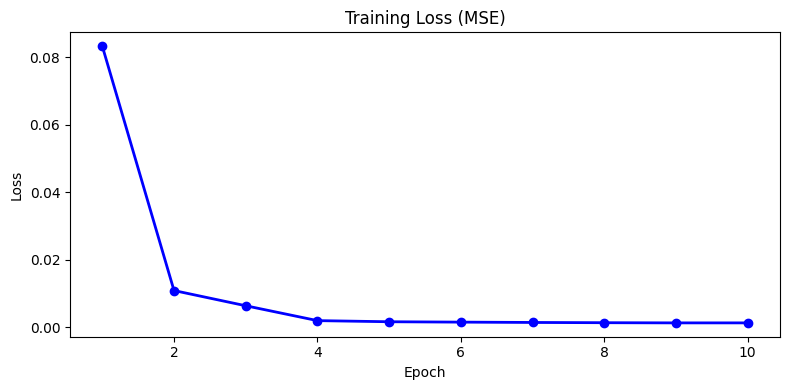

Model saved to text_enhance_cnn.pth


In [10]:
model = TextEnhanceCNN(scale_factor = 2)
train(model, dataloader, epochs=10)

In [53]:
#Test 1
import numpy as np
import cv2

model = TextEnhanceCNN(scale_factor = 2)
model.load_state_dict(torch.load("text_enhance_cnn.pth"))
model.eval()
print("Loaded saved model")

raw_image1 = cv2.imread("Images/Test_1_Zoom_Out.png")
enhanced_image1 = preprocess(raw_image1, model)

raw_result1 = reader.readtext(raw_image1, detail=0)
enhanced_result1 = reader.readtext(enhanced_image1, detail=0)

print("Raw OCR Test 1 on zoomed out image:     ", raw_result1)
print("Enhanced OCR Test 1 on zoomed out image:", enhanced_result1)





Loaded saved model
Raw OCR Test 1 on zoomed out image:      ['SANTA CLARA UNIVERSITY', 'Student Outcomes Self Assessment', 'CSEN 178, Jahangiri; Spring', '2026', 'Yqun(Lsdonsensbeenteconed']
Enhanced OCR Test 1 on zoomed out image: ['SANTA CLARA UNIVERSITY', 'Student Outcomes Self Assessment', 'CSEN 178, Jahangiri, Spring', '2026', 'Your response hvas been recorded.']


In [54]:
#TEST 2
import textwrap
raw_image2 = cv2.imread("Images/Test_2_Zoom_Out.png")
enhanced_image2 = preprocess(raw_image2, model)

raw_text2      = " ".join(reader.readtext(raw_image2, detail=0))
enhanced_text2 = " ".join(reader.readtext(enhanced_image2, detail=0))

print("Raw OCR Test 2:     ", textwrap.fill(raw_text2,      width=80, subsequent_indent="           "))
print("Enhanced OCR Test 2:     ", textwrap.fill(enhanced_text2, width=80, subsequent_indent="           "))

Raw OCR Test 2:      Specialized Groups of Drivers Tne DMV olfers tipS nelp unique groups Iike teens
           senicns Velerans Gisabled peisons new Californians; commnencia
           amvers; and metorcyclists -successfully complete thei: DMVbusiness
           and slay safe on the road Califomia Gude Teen Diiver GuGe Sen %
           Dravei Gude
Enhanced OCR Test 2:      Specialized Groups of Drivers The DMV offers tips t0 help unique groups-like
           teens seniors. veterans; disabled persons new Californians.
           commercial drivers; and motorcyclists-successfully complete their DMV
           business and stay safe on the road_ Ncw to Califomnia Gude Tcen
           Diivei Guice Senior Diiveus Guide


In [55]:
#TEST 3
raw_image3 = cv2.imread("Images/Test_3_Zoom_Out.png")
enhanced_image3 = preprocess(raw_image3, model)

raw_text3     = " ".join(reader.readtext(raw_image3, detail=0))
enhanced_text3 = " ".join(reader.readtext(enhanced_image3, detail=0))

print("Raw OCR Test 3:     ", textwrap.fill(raw_text3,      width=80, subsequent_indent="           "))
print("Enhanced OCR Test 3:     ", textwrap.fill(enhanced_text3, width=80, subsequent_indent="           "))

Raw OCR Test 3:      Have you included us in your Estate Plan? IcuzKno Istn de dncilnle tothe
           exentallc *a5 M Scuacr 94-1156517. Ifyo] oiescn: lease cotact the
           Development Omf ce at 408-531-2100 or eutsand tecc{OsAScMedu:
Enhanced OCR Test 3:      Have you included uS in your Estate Plan? LAtUs Knon Your gift Is deductible %0
           the extent allowab e by lam SCU s tax ID is 94-1156517.Il you have
           quest ons. please contact the Cevelopment Office at 408-554-2100 or
           via emall a: gutsandecciosascuedu: {


In [57]:
#Analytics
import time
import numpy as np

def run_analytics(image_path, model, reader):

    # Raw OCR timing
    raw_image = cv2.imread(image_path)
    H, W = raw_image.shape[:2]

    
    t0 = time.perf_counter()
    raw_result = reader.readtext(raw_image, detail=0)
    raw_time = time.perf_counter() - t0

    #Image enhancement timing
    t1 = time.perf_counter()
    enhanced_image = preprocess(raw_image, model)
    preprocess_time = time.perf_counter() - t1

    #Enhanced OCR timing
    t2 = time.perf_counter()
    enhanced_result = reader.readtext(enhanced_image, detail=0)
    enhanced_ocr_time = time.perf_counter() - t2

    #Total enhanced timing
    total_enhanced_time = preprocess_time + enhanced_ocr_time
    scale = model.scale_factor

    raw_pixels = H * W
    enhanced_pixels = (H * scale) * (W * scale)
    raw_throughput = raw_pixels/raw_time
    enhanced_throughput = enhanced_pixels / total_enhanced_time

    return {
        "image": image_path,
        "raw_time": raw_time,
        "preprocess_time": preprocess_time,
        "enhanced_ocr_time": enhanced_ocr_time,
        "total_enhanced_time": total_enhanced_time,
        "raw_pixels": raw_pixels,
        "enhanced_pixels": enhanced_pixels,
        "raw_throughput_mps": raw_throughput / 1e6,
        "enh_throughput_mps": enhanced_throughput / 1e6,
    }

results = []
for img_path in["Images/Test_1_Zoom_Out.png", "Images/Test_2_Zoom_Out.png", "Images/Test_3_Zoom_Out.png"]:
    results.append(run_analytics(img_path, model, reader))

/Users/timothyle/anaconda3/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


NOTE: Y AXIS VALUES ARE DIFFERENT FOR EACH OF THE GRAPHS

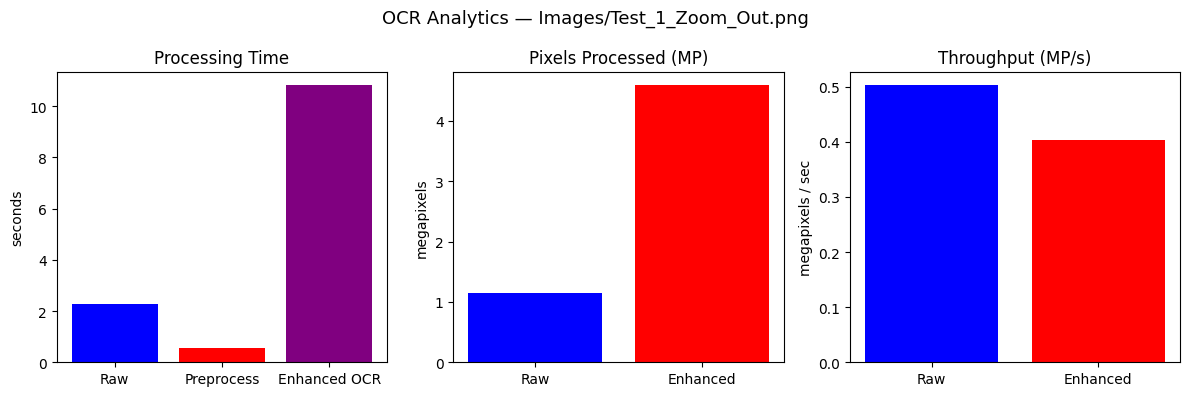

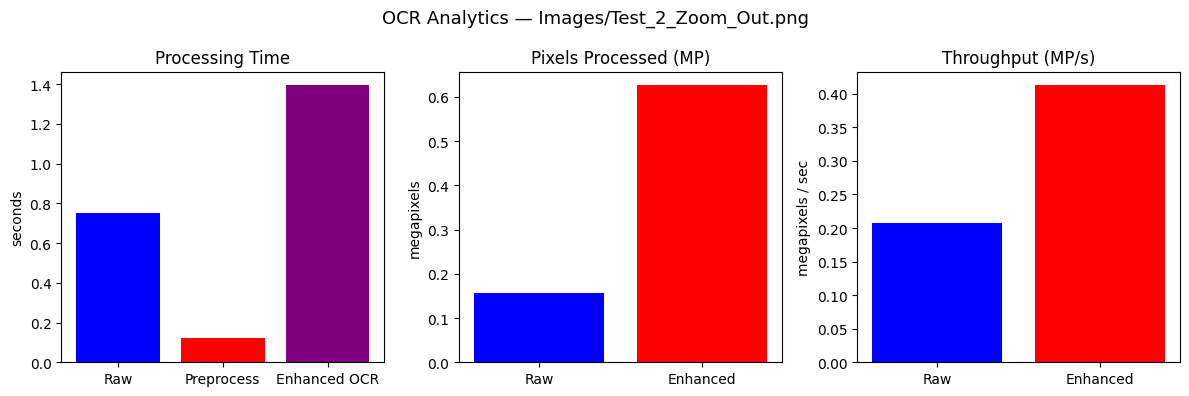

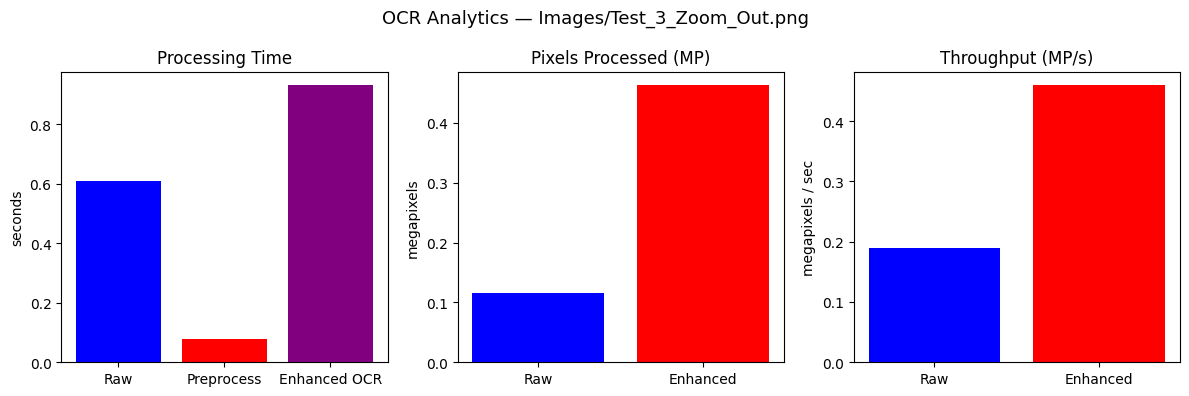

In [58]:
#Visuals
import matplotlib.pyplot as plt

for r in results:
    label = r["image"]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(f"OCR Analytics — {label}", fontsize=13)

    # Processing time
    axes[0].bar(["Raw", "Preprocess", "Enhanced OCR"], 
                [r["raw_time"], r["preprocess_time"], r["enhanced_ocr_time"]],
                color=["blue", "red", "purple"])
    axes[0].set_title("Processing Time")
    axes[0].set_ylabel("seconds")

    # Pixel count
    axes[1].bar(["Raw", "Enhanced"],
                [r["raw_pixels"] / 1e6, r["enhanced_pixels"] / 1e6],
                color=["blue", "red"])
    axes[1].set_title("Pixels Processed (MP)")
    axes[1].set_ylabel("megapixels")

    # Throughput
    axes[2].bar(["Raw", "Enhanced"],
                [r["raw_throughput_mps"], r["enh_throughput_mps"]],
                color=["blue", "red"])
    axes[2].set_title("Throughput (MP/s)")
    axes[2].set_ylabel("megapixels / sec")

    plt.tight_layout()
    plt.savefig("ocr_analytics.png", dpi=150, bbox_inches="tight")
    plt.show()